## Group differences

1. a. (also test general SD/min-max-diff of whole gradient)
1. Within NPC dispersion
2. Betwen network dispersion
3. Illustrate Network dispersions

Findings/Problems
- alignment problems...(less subs) --> was dues to reusing old CC-mask, with new CC-mask all fine :) 
- general SD/min-max-diff correlates with NPC dispersion, but not significantly different between groups for (32P)

ToDo
- GMs within NPC ?! 
- check grad-3 in pycortex for subs with large NPC-dispersion...
- Correlate Vis2-dorsalAtt-FC-strength with NPC-dispersion & Vis2-dorsalAtt-BN-dispersion...
- Correlate between ∂PostPreProc-strategies 

In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
from brainspace.gradient import GradientMaps
from utils import get_basic_mask
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

plot_folder = op.join(bids_folder_orig, 'plots_and_ims/gradient_stuff')
phenotype_folder = op.join(bids_folder_orig, 'derivatives/phenotype')

from os import listdir
#subList = [f[4:6] for f in listdir(op.join(bids_folder_orig)) if f[0:4] == 'sub-' and len(f)==6]
subList = [f'{int(sub):02d}' for sub in range(1, 67)]

fsaverage = fetch_surf_fsaverage('fsaverage5') 

# add group info
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()



In [85]:
confspec = 'oldConfounds'
n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder_orig, 'derivatives', f'gradients', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])

In [28]:
confspec='32P'
frames_per_run_thresh=104
scrub_thresh=0.3

confspec += f'scrub{str(scrub_thresh)[2]}'  #if scrubbing else confspec
confspec += 'BPfilter' #if bp_filtering else confspec
confspec += f'runFD{str(frames_per_run_thresh)}' #if run_FD_filter else confspec
print(confspec)

## load in gradients

n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder, 'derivatives', f'gradients.{confspec}', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])


32Pscrub3BPfilterrunFD104


In [29]:
dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

### overall Dispersion/Variance in gradients


In [4]:
grad_variance = df_gms.std(axis=1).to_frame(name='grad_std')
grad_minmaxdiff = (df_gms.max(axis=1) - df_gms.min(axis=1)).to_frame(name='grad_minmaxdiff')

grad_stats = pd.concat([grad_variance, grad_minmaxdiff], axis=1)


grad_std - not normal distribution (reject H0)
36Pscrub3BPfilterrunFD104
MannwhitneyuResult(statistic=381.0, pvalue=0.03658296750037626)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


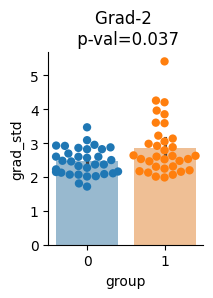

In [ ]:
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

n_grad = 2
y_var =  'grad_std'#'grad_minmaxdiff' #
tmp = grad_stats.xs(n_grad, level='n_gradient')#.drop(64)

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
axes.set(title=f'Grad-{n_grad} \n p-val={stats.pvalue:.3f}',
    ylabel=y_var, xlabel='group')#,ylim=[0,15])
sns.despine()
print(confspec)
print(stats)

## 1. Within NPC dispersion

In [8]:
from utils import get_NPC_mask, get_basic_mask

nprf_r2 = get_NPC_mask()
mask, labeling_noParcel = get_basic_mask()

np.shape(nprf_r2)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


(20484,)

In [24]:
# take NPC as a network and compute dispersion
n_grad = 1
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

# get the gradient loadings of the nodes of the ROI, for each subject (shape: number of nodes in network x N)
G1_net = g1[nprf_r2]

centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N

NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis = 0) 

df = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))

df =  df.sort_index(level='subject')
df.head()


,,NPC_dispersion,NPC_centroid
subject,group,,
1,0,2.035572,1.673781
2,1,3.478073,1.940010
3,0,5.938145,0.075008
4,1,7.618163,0.539487
5,0,2.906828,-0.023785


In [ ]:
# 2D dispersion measure
n_grad = 'both 2D'

g1 = np.array(gms_aligned[f'g1']).T
g2 = np.array(gms_aligned[f'g2']).T

G1_net = g1[nprf_r2]
G2_net = g2[nprf_r2]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2

centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion =  np.nanmean(squared_distances, axis=0)  # shape: N

df = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
#n_grad = 'both2D'
#df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}_confspec-{confspec}.csv'))



In [14]:
y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 
df.loc[df[y_var].idxmax()]

NPC_2D_dispersion    40.85059
Name: (46, 1), dtype: float64

NPC_2D_dispersion - not normal distribution (reject H0)
36Pscrub3BPfilterrunFD104
MannwhitneyuResult(statistic=336.0, pvalue=0.011978202793541844)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


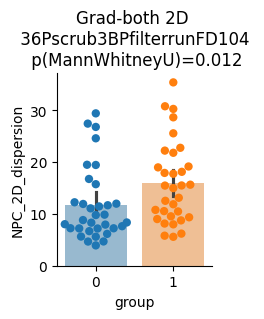

In [15]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import normaltest
alpha = 0.05 # threshold for normality

y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 

max_index = df[y_var].idxmax() # sub-06 weird... 
tmp = df.drop(index=max_index)
#tmp = tmp.drop(index=tmp[y_var].idxmax())
#tmp = tmp.drop(index=tmp[y_var].idxmax())
#tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
        test_name = 't-test'
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
        test_name = 'MannWhitneyU'
axes.set(title=f'Grad-{n_grad} \n {confspec} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
sns.despine()
print(confspec)
print(stats)


In [ ]:
df_comb = df.join(grad_stats.xs(n_grad, level='n_gradient'))
df_comb.corr()

,NPC_dispersion,NPC_centroid,grad_std,grad_minmaxdiff
NPC_dispersion,1.000000,0.068793,0.129886,0.014937
NPC_centroid,0.068793,1.000000,0.670094,0.671022
grad_std,0.129886,0.670094,1.000000,0.992463
grad_minmaxdiff,0.014937,0.671022,0.992463,1.000000


In [68]:
import pingouin as pg

print(pg.corr(df_comb['NPC_centroid'],df_comb['grad_std'], method='pearson'))
pg.corr(df_comb['NPC_dispersion'],df_comb['grad_std'], method='pearson')

          n         r         CI95%         p-val       BF10     power
pearson  66  0.670094  [0.51, 0.78]  7.576419e-10  1.678e+07  0.999997


,n,r,CI95%,p-val,BF10,power
pearson,66,0.129886,"[-0.12, 0.36]",0.298597,0.261,0.180814


## 2. Between Network Dispersion

In [31]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

In [22]:
## remove outlier subs, they make everything look weird
# for 32P: sub-6; for 36P: sub-64

confspec = '32Pscrub3BPfilterrunFD104'
subList = [f'{int(sub):02d}' for sub in range(1, 67)]
subList.remove('64') # weird outlier

n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder, 'derivatives', f'gradients.{confspec}', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])
print(sub_array)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 65 66]


In [23]:
# 1D
n_grad = 2
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

N_nets = len(np.unique(caNets_fsav5_mapping)[1:]) # remove network-label=0
centroids_net = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x 1000)
for n_network in np.unique(caNets_fsav5_mapping)[1:]:
    netNodes = np.where(caNets_fsav5_mapping == (n_network))[0] # get (glasser space) indices
    netNodes = np.squeeze(netNodes)
    G1_net = g1[netNodes]
    centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
    centroids_net.append(centroid_cog_net)

centroids_net = np.array(centroids_net)


In [15]:
# 2D
n_grad = 'both 2D'

g1 = np.array(gms_aligned['g1']).T 
g2 = np.array(gms_aligned['g2']).T 

N_nets = 12
centroids_net = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x 1000)
for n_network in np.unique(caNets_fsav5_mapping)[1:]:
    netNodes = np.where(caNets_fsav5_mapping == (n_network))[0]  # get (Glasser space) indices
    netNodes = np.squeeze(netNodes)
    G1_net = g1[netNodes]  # shape: number of nodes in network x N
    G2_net = g2[netNodes]  # shape: number of nodes in network x N
    G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2
    centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2
    centroids_net.append(centroid_cog_net)
    
centroids_net = np.array(centroids_net)  # shape: N_nets x N_subs x 2 


In [24]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

test_name =  '2sample_TTest' #'mannwhitneyu'# # most not normally distributed...., but vmin/vmax in next step have to be adapted!

N_nets = 12
mat_pvals = np.ones([N_nets, N_nets])
mat_rs = np.zeros([N_nets, N_nets]) # = Tvals !
mat_outliers = np.zeros([N_nets, N_nets])

distances = []
net_name_comps = []
for n1 in range(N_nets):
    for n2 in range(n1, N_nets):
        if n_grad == 'both 2D':
            distance = np.linalg.norm(centroids_net[n1] - centroids_net[n2], axis=1)
        else:
            distance = np.abs(centroids_net[n1] - centroids_net[n2]) # (12, 66)
        distances.append(distance)

        df = pd.DataFrame(np.array(distance.T), index=sub_array,columns=['net_distance'])
        df.index.name = 'subject'
        df = df.join(group_list['group']).set_index('group',append=True)
        if test_name == '2sample_TTest':
            t_stat, p_val = ttest_ind(df.xs(0,0,'group'), df.xs(1,0,'group'), equal_var=False)
        elif test_name == 'mannwhitneyu':
            t_stat, p_val = mannwhitneyu(df.xs(0,0,'group'), df.xs(1,0,'group'), axis=0)
        else:
            raise ValueError('test_name not recognized')
        mat_rs[n1,n2] = np.round(t_stat, 3)
        mat_pvals[n1,n2] =  np.round(p_val, 4)

        net_name_comps.append(str(CAatlas_names.loc[n1+1]['Network Name']) +  ' - ' + str(CAatlas_names.loc[n2+1]['Network Name']))


/tmp/ipykernel_1883073/4127846297.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_rs[n1,n2] = np.round(t_stat, 3)
/tmp/ipykernel_1883073/4127846297.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_pvals[n1,n2] =  np.round(p_val, 4)
/tmp/ipykernel_1883073/4127846297.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_rs[n1,n2] = np.round(t_stat, 3)
/tmp/ipykernel_1883073/4127846297.py:31: DeprecationWarning: Conversion of an array with ndim > 0

Text(0.5, 1.1, '2sample_TTest Between network distance group difference \n 32Pscrub3BPfilterrunFD104 \n Grad 2')

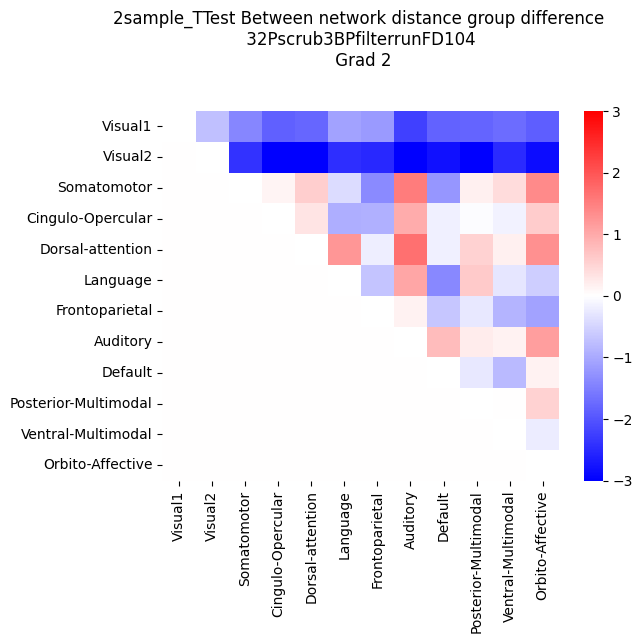

In [25]:
sns.heatmap(mat_rs, cmap='bwr',vmin=-3,vmax=3,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'{test_name} Between network distance group difference \n {confspec} \n Grad {n_grad}', y=1.1)

Text(0.5, 1.02, 'P-vals of between group TTEst on between network distances \n 32Pscrub3BPfilterrunFD104 \n Grad 2')

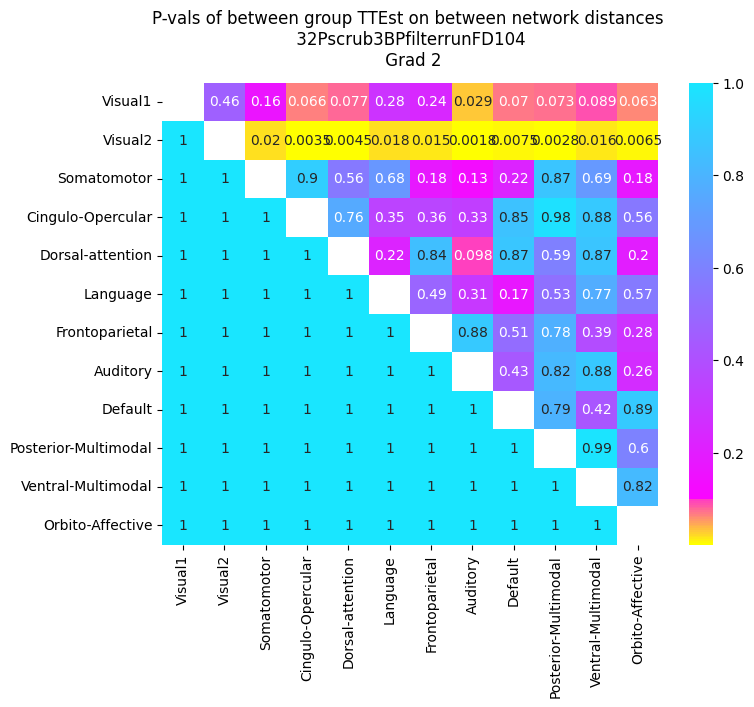

In [26]:
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap
pval_cmap = get_pval_colormap()

fig, axes = plt.subplots(1,1, figsize=(8,6)) # , sharex=True, sharey=True

sns.heatmap(mat_pvals, cmap=pval_cmap,annot=True,ax=axes, #vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'P-vals of between group TTEst on between network distances \n {confspec} \n Grad {n_grad}', y=1.02)

In [27]:
pvals = mat_pvals.flatten()
pvals = pvals[pvals != 1]
pvals = [x for x in pvals if not np.isnan(x)]
pvals

# Apply Benjamini-Hochberg FDR correction
from statsmodels.stats.multitest import multipletests
_, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
#print(pvals_corrected)

mask = (mat_pvals != 1) & ~np.isnan(mat_pvals)
corrected_mat_pvals = np.full(mat_pvals.shape, np.nan)
corrected_mat_pvals[mask] = pvals_corrected

In [28]:
# only multiple comparison over networks contained within NPC mask
network_labels = range(1, 13)
NPC_nets = [ 1,  2,  3,  4,  5,  7,  9, 10]
region_mask = np.isin(network_labels, NPC_nets)  # network_labels should match mat_pvals structure

mask = (mat_pvals != 1) & ~np.isnan(mat_pvals) & region_mask
pvals = mat_pvals[mask]
pvals = pvals[~np.isnan(pvals)]

from statsmodels.stats.multitest import multipletests
_, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Create a new matrix for corrected p-values
corrected_mat_pvals = np.full(mat_pvals.shape, np.nan)
mask = (mat_pvals != 1) & ~np.isnan(mat_pvals) & region_mask
corrected_mat_pvals[mask] = pvals_corrected

Text(0.5, 1.01, 'Corrected  P-vals \n 2sample_TTest - between network distance\n 32Pscrub3BPfilterrunFD104 \nGrad 2')

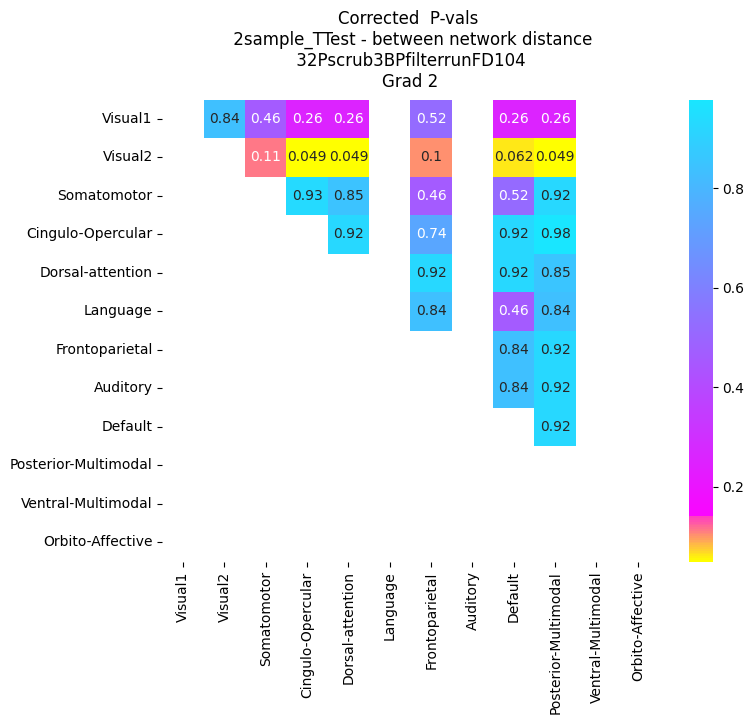

In [29]:
fig, axes = plt.subplots(1,1, figsize=(8,6)) # , sharex=True, sharey=True
sns.heatmap(corrected_mat_pvals, cmap=pval_cmap,annot=True,ax=axes, #vmin=0.05,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Corrected  P-vals \n {test_name} - between network distance\n {confspec} \nGrad {n_grad}', y=1.01)

## Illustrate Network dispersions

In [34]:
n_grad = 2
tmp = df_gms.xs(n_grad,0,'n_gradient')#.drop(index=6).drop(index=18) # subject 6 weird..
df = pd.DataFrame(np.array([tmp.xs(0,0,'group').mean().values, tmp.xs(1,0,'group').mean().values, caNets_fsav5_mapping]).T,
                         columns =['control','dyscalc','ca_network' ]) 


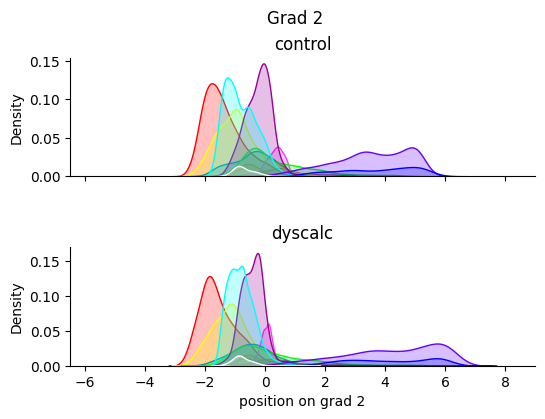

In [35]:
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

fig, axs = plt.subplots(2,1,figsize=(6,4), sharex=True)
sns.kdeplot(df,hue='ca_network',x='control',fill=True,palette=ca_cmap, ax=axs[0],legend=False )
sns.kdeplot(df,hue='ca_network',x='dyscalc',fill=True,palette=ca_cmap, ax=axs[1],legend=False )
fig.subplots_adjust(hspace=0.6)
axs[0].set(title='control', xlim=(-6.5,9))
axs[1].set(title='dyscalc', xlabel=f'position on grad {n_grad}')#, xlim=(-6.5,9))
fig.suptitle(f'Grad {n_grad}',y=1)

sns.despine()


In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for each column
z_scores = df_gms.apply(zscore)

# Define outliers as values with Z-scores > 3 or < -3
outliers = (z_scores.abs() > 3)

print(outliers)